# CSE 472: Machine Learning Sessional Assignment 1
## Medical Students Dataset Analysis & Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


### 3.1 Understanding the dataset

In [2]:
# 1. Import the dataset
df = pd.read_csv('/kaggle/input/med-stud/medical_students_dataset - medical_students_dataset.csv')

# 2. Show number of attributes and records
print(f"Number of attributes (columns): {df.shape[1]}")
print(f"Number of records (rows): {df.shape[0]}")

# 3. Statistics of the dataset
print("\nDataset Statistics:")
display(df.describe())

# 4. Count missing values
print("\nMissing Values per column:")
print(df.isnull().sum())

# 5. Count duplicate values
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

Number of attributes (columns): 13
Number of records (rows): 200000

Dataset Statistics:


,Student ID,Age,Height,Weight,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol
count,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000
mean,49974.042078,26.021561,174.947103,69.971585,23.338869,98.600948,79.503767,114.558033,184.486361
std,28879.641657,4.890528,14.447560,17.322574,7.033554,0.500530,11.540755,14.403353,37.559678
min,1.000000,18.000000,150.000041,40.000578,10.074837,96.397835,60.000000,90.000000,120.000000
25%,24971.750000,22.000000,162.476110,54.969838,17.858396,98.264750,70.000000,102.000000,152.000000
50%,49943.500000,26.000000,174.899914,69.979384,22.671401,98.599654,80.000000,115.000000,184.000000
75%,74986.000000,30.000000,187.464417,84.980097,27.997487,98.940543,90.000000,127.000000,217.000000
max,100000.000000,34.000000,199.998639,99.999907,44.355113,100.824857,99.000000,139.000000,249.000000



Missing Values per column:
Student ID        20000
Age               20000
Gender            20000
Height            20000
Weight            20000
Blood Type        20000
BMI               20000
Temperature       20000
Heart Rate        20000
Blood Pressure    20000
Cholesterol       20000
Diabetes          20000
Smoking           20000
dtype: int64

Number of duplicate rows: 7644

Number of duplicate rows: 7644


### 3.2 Data Cleaning

In [3]:
# 1. Impute missing values with column mean (for numeric columns)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# 2. Remove duplicates
df_cleaned = df.drop_duplicates()
print(f"Rows after dropping duplicates: {df_cleaned.shape[0]}")

# 3. Drop rows where 'Diabetes' is missing
df_cleaned = df_cleaned.dropna(subset=['Diabetes'])
print(f"Rows after dropping missing Diabetes targets: {df_cleaned.shape[0]}")

Rows after dropping duplicates: 192356
Rows after dropping missing Diabetes targets: 172451


### 3.3 Creation of input and output features

In [4]:
X = df_cleaned.drop(columns=['Diabetes'])
y = df_cleaned['Diabetes']

In [5]:
# Count target classes
y_str = y.astype(str).str.strip().str.lower()
positive_cases = (y_str == 'yes').sum()
negative_cases = (y_str == 'no').sum()

print(f"Number of positive diabetes cases (Yes): {int(positive_cases)}")
print(f"Number of negative diabetes cases (No): {int(negative_cases)}")
print(f"Minority class: {'Yes (Diabetes)' if positive_cases < negative_cases else 'No (Healthy)'}")

Number of positive diabetes cases (Yes): 17286
Number of negative diabetes cases (No): 155165
Minority class: Yes (Diabetes)


### 3.4 Conversion of features into numeric values

In [ ]:
# Drop Student ID
if 'Student ID' in X.columns:
    X = X.drop(columns=['Student ID'])

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"Categorical columns: {list(categorical_cols)}")

# Convert Target 'Diabetes' to numeric
y = y.map({'Yes': 1, 'No': 0})

# Apply One-Hot Encoding to categorical features
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False) 

print("Columns after encoding:")
print(X_encoded.columns)

Categorical columns: ['Gender', 'Blood Type', 'Smoking']
Columns after encoding:
Index(['Age', 'Height', 'Weight', 'BMI', 'Temperature', 'Heart Rate',
       'Blood Pressure', 'Cholesterol', 'Gender_Female', 'Gender_Male',
       'Blood Type_A', 'Blood Type_AB', 'Blood Type_B', 'Blood Type_O',
       'Smoking_No', 'Smoking_Yes'],
      dtype='object')
Columns after encoding:
Index(['Age', 'Height', 'Weight', 'BMI', 'Temperature', 'Heart Rate',
       'Blood Pressure', 'Cholesterol', 'Gender_Female', 'Gender_Male',
       'Blood Type_A', 'Blood Type_AB', 'Blood Type_B', 'Blood Type_O',
       'Smoking_No', 'Smoking_Yes'],
      dtype='object')


### 3.5 Scaling of the features

In [ ]:
def scale_features(df, columns, method='minmax'):
    df_scaled = df.copy()
    existing_cols = [c for c in columns if c in df_scaled.columns]
    if not existing_cols:
        return df_scaled

    if method == 'standard':
        scaler = StandardScaler()
    elif method == 'minmax':
        scaler = MinMaxScaler()
    else:
        raise ValueError("method must be 'standard' or 'minmax'")

    df_scaled[existing_cols] = scaler.fit_transform(df_scaled[existing_cols])
    return df_scaled

# Identify columns to scale
cols_to_scale = [col for col in X.columns if col not in categorical_cols]
print(f"Columns to scale: {cols_to_scale}")

Columns to scale: ['Age', 'Height', 'Weight', 'BMI', 'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol']


In [8]:
X_encoded.head()

,Age,Height,Weight,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Gender_Female,Gender_Male,Blood Type_A,Blood Type_AB,Blood Type_B,Blood Type_O,Smoking_No,Smoking_Yes
0,18.000000,161.777924,72.354947,27.645835,98.600948,95.0,109.000000,203.0,True,False,False,False,False,True,False,False
1,26.021561,152.069157,47.630941,23.338869,98.714977,93.0,104.000000,163.0,False,True,False,False,True,False,True,False
2,32.000000,182.537664,55.741083,16.729017,98.260293,76.0,130.000000,216.0,True,False,True,False,False,False,True,False
3,30.000000,182.112867,63.332207,19.096042,98.839605,99.0,112.000000,141.0,False,True,False,False,True,False,False,True
4,23.000000,174.947103,46.234173,23.338869,98.480008,95.0,114.558033,231.0,True,False,False,False,False,True,True,False


In [9]:
# Test both scaling methods to compare
print("Comparing Scaling Methods:")
print("="*60)

# Try MinMax scaling
X_scaled_minmax = scale_features(X_encoded.copy(), cols_to_scale, method='minmax')
print("\nMinMax Scaling:")
print(X_scaled_minmax.head())
print(f"\nValue ranges after MinMax scaling:")
print(X_scaled_minmax.describe().loc[['min', 'max']])

# Try Standard scaling  
X_scaled_standard = scale_features(X_encoded.copy(), cols_to_scale, method='standard')
print("\n" + "="*60)
print("\nStandard Scaling:")
print(X_scaled_standard.head())
print(f"\nValue ranges after Standard scaling:")
print(X_scaled_standard.describe().loc[['mean', 'std']])

print("\n" + "="*60)
print("Both scaling methods will be tested with the model")
print("="*60)

Comparing Scaling Methods:

MinMax Scaling:
        Age    Height    Weight       BMI  Temperature  Heart Rate  \
0  0.000000  0.235564  0.539246  0.512569     0.497651    0.897436   
1  0.501348  0.041383  0.127174  0.386929     0.523409    0.846154   
2  0.875000  0.650771  0.262345  0.194111     0.420702    0.410256   
3  0.750000  0.642275  0.388865  0.263160     0.551560    1.000000   
4  0.312500  0.498955  0.103894  0.386929     0.470333    0.897436   

   Blood Pressure  Cholesterol  Gender_Female  Gender_Male  Blood Type_A  \
0        0.387755     0.643411           True        False         False   
1        0.285714     0.333333          False         True         False   
2        0.816327     0.744186           True        False          True   
3        0.448980     0.162791          False         True         False   
4        0.501184     0.860465           True        False         False   

   Blood Type_AB  Blood Type_B  Blood Type_O  Smoking_No  Smoking_Yes  
0     

### 3.6 Correlation Analysis

In [10]:
# Prepare datasets
scaling_methods = {
    'MinMax': X_scaled_minmax,
    'Standard': X_scaled_standard
}

# Store results
all_scaling_results = {}

In [ ]:
# For each scaling method, select top 10 features
for scaling_name, X_scaled in scaling_methods.items():
    print(f"\n{'='*60}")
    print(f"Feature Selection for {scaling_name} Scaling")
    print('='*60)
    
    df_corr_analysis = X_scaled.copy()
    df_corr_analysis['Diabetes'] = y
    
    # Calculate Correlation Matrix
    corr_matrix = df_corr_analysis.corr()
    
    target_corr = corr_matrix['Diabetes'].drop('Diabetes')
    print(f"\nCorrelation with Target (Diabetes) - Top 10:")
    print(target_corr.abs().sort_values(ascending=False).head(10))
    
    # Select top 10 columns
    top_10_features = target_corr.abs().sort_values(ascending=False).head(10).index
    
    # Store for training
    all_scaling_results[scaling_name] = {
        'X_scaled': X_scaled,
        'top_10_features': top_10_features,
        'X_final': X_scaled[top_10_features].values,
        'y_final': y.values
    }
    
    print(f"Top 10 features: {list(top_10_features)}")

print(f"\n{'='*60}")
print("Feature selection complete for both scaling methods")
print('='*60)


Feature Selection for MinMax Scaling

Correlation with Target (Diabetes) - Top 10:
Height           0.006280
Temperature      0.005865
Age              0.004108
Cholesterol      0.002683
Gender_Female    0.002610
Smoking_No       0.002495
Gender_Male      0.002360
Weight           0.002343
BMI              0.001908
Heart Rate       0.001679
Name: Diabetes, dtype: float64
Top 10 features: ['Height', 'Temperature', 'Age', 'Cholesterol', 'Gender_Female', 'Smoking_No', 'Gender_Male', 'Weight', 'BMI', 'Heart Rate']

Feature Selection for Standard Scaling

Correlation with Target (Diabetes) - Top 10:
Height           0.006280
Temperature      0.005865
Age              0.004108
Cholesterol      0.002683
Gender_Female    0.002610
Smoking_No       0.002495
Gender_Male      0.002360
Weight           0.002343
BMI              0.001908
Heart Rate       0.001679
Name: Diabetes, dtype: float64
Top 10 features: ['Height', 'Temperature', 'Age', 'Cholesterol', 'Gender_Female', 'Smoking_No', 'Gender_Ma

### 3.7 Validating the Pipeline (FNN with PyTorch)

In [ ]:
# Train models
results_by_scaling = {}

for scaling_name in ['MinMax', 'Standard']:
    print(f"\n{'='*80}")
    print(f"TRAINING WITH {scaling_name.upper()} SCALING")
    print('='*80)
    
    X_final = all_scaling_results[scaling_name]['X_final']
    y_final = all_scaling_results[scaling_name]['y_final']
    
    # Stratified Split 70:15:15
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_final, y_final, test_size=0.3, stratify=y_final, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
    )
    
    # Check class distribution
    unique, counts = np.unique(y_train, return_counts=True)
    print(f"\nTraining set class distribution: {dict(zip(unique, counts))}")
    print(f"Class 0 (No Diabetes): {counts[0]} samples ({counts[0]/len(y_train)*100:.2f}%)")
    print(f"Class 1 (Yes Diabetes): {counts[1]} samples ({counts[1]/len(y_train)*100:.2f}%)")
    
    # Identify which class is minority
    if counts[0] < counts[1]:
        minority_class = 0
        majority_class = 1
        print(f"\n WARNING: Class 0 (No Diabetes) is the MINORITY class!")
        print(f"Consider re-mapping labels so the minority class is positive (1)")
    else:
        minority_class = 1
        majority_class = 0
        print(f"\n Class 1 (Yes Diabetes) is the minority class (as expected)")
    
    # Calculate class weights for handling imbalance
    pos_weight = counts[0] / counts[1]
    print(f"\nPositive class weight (for BCEWithLogitsLoss): {pos_weight:.2f}")
    print(f"This gives {pos_weight:.2f}x more penalty for misclassifying class 1 (Yes Diabetes)")
    
    # If pos_weight < 1, class 1 is actually the majority
    if pos_weight < 1.0:
        print(f"\n ERROR: pos_weight={pos_weight:.2f} < 1.0")
        print(f"This means class 1 has MORE samples than class 0!")
        print(f"The weight will actually REDUCE penalties for class 1, making imbalance worse.")
        print(f"\nCorrect approach: Use pos_weight = {1/pos_weight:.2f} (inverse)")
        pos_weight = 1 / pos_weight
        print(f"Adjusted pos_weight to: {pos_weight:.2f}")
    
    # Convert to float32 to ensure compatibility with PyTorch
    X_train = X_train.astype(np.float32)
    X_val = X_val.astype(np.float32)
    X_test = X_test.astype(np.float32)
    y_train = y_train.astype(np.float32)
    y_val = y_val.astype(np.float32)
    y_test = y_test.astype(np.float32)
    
    # Convert to PyTorch Tensors
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
    X_val_tensor = torch.FloatTensor(X_val)
    y_val_tensor = torch.FloatTensor(y_val).unsqueeze(1)
    X_test_tensor = torch.FloatTensor(X_test)
    y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)
    
    print(f"\nTrain shape: {X_train_tensor.shape}, Val shape: {X_val_tensor.shape}, Test shape: {X_test_tensor.shape}")
    
    # Store for this scaling method
    results_by_scaling[scaling_name] = {
        'X_train_tensor': X_train_tensor,
        'y_train_tensor': y_train_tensor,
        'X_val_tensor': X_val_tensor,
        'y_val_tensor': y_val_tensor,
        'X_test_tensor': X_test_tensor,
        'y_test_tensor': y_test_tensor,
        'y_test': y_test,
        'pos_weight': pos_weight
    }


TRAINING WITH MINMAX SCALING

Training set class distribution: {0: 108615, 1: 12100}
Class 0 (No Diabetes): 108615 samples (89.98%)
Class 1 (Yes Diabetes): 12100 samples (10.02%)

✓ Class 1 (Yes Diabetes) is the minority class (as expected)

Positive class weight (for BCEWithLogitsLoss): 8.98
This gives 8.98x more penalty for misclassifying class 1 (Yes Diabetes)

Train shape: torch.Size([120715, 10]), Val shape: torch.Size([25868, 10]), Test shape: torch.Size([25868, 10])

TRAINING WITH STANDARD SCALING

Training set class distribution: {0: 108615, 1: 12100}
Class 0 (No Diabetes): 108615 samples (89.98%)
Class 1 (Yes Diabetes): 12100 samples (10.02%)

✓ Class 1 (Yes Diabetes) is the minority class (as expected)

Positive class weight (for BCEWithLogitsLoss): 8.98
This gives 8.98x more penalty for misclassifying class 1 (Yes Diabetes)

Train shape: torch.Size([120715, 10]), Val shape: torch.Size([25868, 10]), Test shape: torch.Size([25868, 10])

TRAINING WITH STANDARD SCALING

Trainin

In [ ]:
# Define FNN Architecture (logits output; sigmoid applied only for probabilities)
class DiabetesFNN(nn.Module):
    def __init__(self, input_dim, hidden_layers, output_dim=1):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_one_arch(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=200,
    patience=20,
    model_path='best_model.pth',
):
    best_val = float('inf')
    best_epoch = -1
    patience_left = patience
    train_losses = []
    val_losses = []

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        n = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
            n += xb.size(0)
        train_loss = running / max(n, 1)
        train_losses.append(train_loss)

        model.eval()
        running = 0.0
        n = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                logits = model(xb)
                loss = criterion(logits, yb)
                running += loss.item() * xb.size(0)
                n += xb.size(0)
        val_loss = running / max(n, 1)
        val_losses.append(val_loss)

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_epoch = epoch
            patience_left = patience
            torch.save(model.state_dict(), model_path)
        else:
            patience_left -= 1
            if patience_left <= 0:
                break

    return train_losses, val_losses, best_val, best_epoch


# Architectures to test
architectures = [
    [32, 16],
    [64, 32],
    [128, 64, 32],
    [256, 128, 64],
]

batch_size = 64

# Dictionary to store all results
all_results = {}

# Train model
for scaling_name in ['MinMax', 'Standard']:
    print(f"\n{'#'*80}")
    print(f"{'#'*80}")
    print(f"  TRAINING ARCHITECTURES WITH {scaling_name.upper()} SCALING")
    print(f"{'#'*80}")
    print(f"{'#'*80}\n")
    
    # Get data for this scaling method
    data = results_by_scaling[scaling_name]
    X_train_tensor = data['X_train_tensor']
    y_train_tensor = data['y_train_tensor']
    X_val_tensor = data['X_val_tensor']
    y_val_tensor = data['y_val_tensor']
    X_test_tensor = data['X_test_tensor']
    y_test_tensor = data['y_test_tensor']
    y_test = data['y_test']
    pos_weight = data['pos_weight']
    
    # Create DataLoaders (mini-batch)
    train_ds = TensorDataset(X_train_tensor.to(device), y_train_tensor.to(device))
    val_ds = TensorDataset(X_val_tensor.to(device), y_val_tensor.to(device))
    test_ds = TensorDataset(X_test_tensor.to(device), y_test_tensor.to(device))
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    
    input_dim = X_train_tensor.shape[1]
    results = {}
    
    for i, hidden_layers in enumerate(architectures, start=1):
        arch_name = f'Arch {i}'
        print(f"\n{'-'*60}")
        print(f"Training {arch_name}: {input_dim} -> {hidden_layers} -> 1")
        print(f"{'-'*60}")
        
        model = DiabetesFNN(input_dim, hidden_layers).to(device)
        
        pos_weight_tensor = torch.tensor([pos_weight], dtype=torch.float32, device=device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        model_path = f'best_model_{scaling_name}_{arch_name.replace(" ", "_")}.pth'
        train_losses, val_losses, best_val, best_epoch = train_one_arch(
            model,
            train_loader,
            val_loader,
            criterion,
            optimizer,
            epochs=200,
            patience=20,
            model_path=model_path,
        )
        
        # Load best weights for this architecture
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()
        
        y_true = []
        y_prob = []
        with torch.no_grad():
            for xb, yb in test_loader:
                logits = model(xb)
                prob = torch.sigmoid(logits)
                y_true.append(yb.detach().cpu().numpy())
                y_prob.append(prob.detach().cpu().numpy())
        
        y_true = np.concatenate(y_true).reshape(-1)
        y_prob = np.concatenate(y_prob).reshape(-1)
        y_pred = (y_prob >= 0.5).astype(np.float32)
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        auroc = roc_auc_score(y_test, y_prob)
        
        results[arch_name] = {
            'hidden_layers': hidden_layers,
            'best_epoch': best_epoch,
            'best_val_loss': best_val,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auroc': auroc,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'model_path': model_path,
        }
        
        print(
            f"Best epoch={best_epoch}, best val loss={best_val:.4f} | "
            f"Acc={accuracy:.4f}, Prec={precision:.4f}, Rec={recall:.4f}, F1={f1:.4f}, AUROC={auroc:.4f}"
        )
    
    # Store results for this scaling method
    all_results[scaling_name] = results
    
    print(f"\n{'='*60}")
    print(f"Completed training for {scaling_name} scaling")
    print(f"{'='*60}\n")


################################################################################
################################################################################
  TRAINING ARCHITECTURES WITH MINMAX SCALING
################################################################################
################################################################################


------------------------------------------------------------
Training Arch 1: 10 -> [32, 16] -> 1
------------------------------------------------------------
Best epoch=3, best val loss=1.2475 | Acc=0.7979, Prec=0.1108, Rec=0.1446, F1=0.1255, AUROC=0.5145

------------------------------------------------------------
Training Arch 2: 10 -> [64, 32] -> 1
------------------------------------------------------------
Best epoch=5, best val loss=1.2475 | Acc=0.1961, Prec=0.1002, Rec=0.8793, F1=0.1799, AUROC=0.5134

------------------------------------------------------------
Training Arch 3: 10 -> [128, 64, 32] -> 1
---------

In [ ]:
# Compare results between MinMax and Standard scaling
print("\n" + "="*80)
print("COMPARISON: MinMax Scaling vs Standard Scaling")
print("="*80)

comparison_data = []

for scaling_name in ['MinMax', 'Standard']:
    print(f"\n{scaling_name} Scaling Results:")
    print("-" * 60)
    results = all_results[scaling_name]
    
    for arch_name, metrics in results.items():
        print(
            f"{arch_name} {metrics['hidden_layers']}: "
            f"Acc={metrics['accuracy']:.4f}, Prec={metrics['precision']:.4f}, "
            f"Rec={metrics['recall']:.4f}, F1={metrics['f1']:.4f}, AUROC={metrics['auroc']:.4f}"
        )
        
        comparison_data.append({
            'Scaling': scaling_name,
            'Architecture': arch_name,
            'Accuracy': metrics['accuracy'],
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1': metrics['f1'],
            'AUROC': metrics['auroc']
        })

# Calculate average metrics for each scaling method
print("\n" + "="*80)
print("AVERAGE PERFORMANCE BY SCALING METHOD")
print("="*80)

for scaling_name in ['MinMax', 'Standard']:
    results = all_results[scaling_name]
    avg_acc = np.mean([m['accuracy'] for m in results.values()])
    avg_prec = np.mean([m['precision'] for m in results.values()])
    avg_rec = np.mean([m['recall'] for m in results.values()])
    avg_f1 = np.mean([m['f1'] for m in results.values()])
    avg_auroc = np.mean([m['auroc'] for m in results.values()])
    
    print(f"\n{scaling_name} Scaling (Average across all architectures):")
    print(f"  Accuracy:  {avg_acc:.4f}")
    print(f"  Precision: {avg_prec:.4f}")
    print(f"  Recall:    {avg_rec:.4f}")
    print(f"  F1-score:  {avg_f1:.4f}")
    print(f"  AUROC:     {avg_auroc:.4f}")

# Determine which scaling method is better
minmax_avg_f1 = np.mean([m['f1'] for m in all_results['MinMax'].values()])
standard_avg_f1 = np.mean([m['f1'] for m in all_results['Standard'].values()])

print("\n" + "="*80)
print("CONCLUSION")
print("="*80)

if minmax_avg_f1 > standard_avg_f1:
    print(f"MinMax Scaling performs BETTER (Avg F1: {minmax_avg_f1:.4f} vs {standard_avg_f1:.4f})")
    best_scaling = 'MinMax'
elif standard_avg_f1 > minmax_avg_f1:
    print(f"Standard Scaling performs BETTER (Avg F1: {standard_avg_f1:.4f} vs {minmax_avg_f1:.4f})")
    best_scaling = 'Standard'
else:
    print(f"Both scaling methods perform equally (Avg F1: {minmax_avg_f1:.4f})")
    best_scaling = 'MinMax'  # Default to MinMax in case of tie

print(f"\nBest scaling method: {best_scaling}")
print("="*80)


COMPARISON: MinMax Scaling vs Standard Scaling

MinMax Scaling Results:
------------------------------------------------------------
Arch 1 [32, 16]: Acc=0.7979, Prec=0.1108, Rec=0.1446, F1=0.1255, AUROC=0.5145
Arch 2 [64, 32]: Acc=0.1961, Prec=0.1002, Rec=0.8793, F1=0.1799, AUROC=0.5134
Arch 3 [128, 64, 32]: Acc=0.4584, Prec=0.1046, Rec=0.5823, F1=0.1773, AUROC=0.5188
Arch 4 [256, 128, 64]: Acc=0.4450, Prec=0.1022, Rec=0.5827, F1=0.1739, AUROC=0.5099

Standard Scaling Results:
------------------------------------------------------------
Arch 1 [32, 16]: Acc=0.5853, Prec=0.1063, Rec=0.4234, F1=0.1699, AUROC=0.5182
Arch 2 [64, 32]: Acc=0.5857, Prec=0.1070, Rec=0.4265, F1=0.1711, AUROC=0.5193
Arch 3 [128, 64, 32]: Acc=0.8032, Prec=0.1032, Rec=0.1253, F1=0.1132, AUROC=0.5054
Arch 4 [256, 128, 64]: Acc=0.4159, Prec=0.1035, Rec=0.6302, F1=0.1778, AUROC=0.5116

AVERAGE PERFORMANCE BY SCALING METHOD

MinMax Scaling (Average across all architectures):
  Accuracy:  0.4744
  Precision: 0.1044
 

### 3.8 Report

## Architecture Experiment Summary

### Architectures Tested (Feed-Forward Neural Networks)
All models are fully-connected MLPs for binary classification (Diabetes: Yes/No). Each architecture has **2–3 hidden layers** and uses a decreasing width pattern (higher capacity to lower capacity).

| Architecture | Network Structure | Number of Layers | Parameters per Layer | Total Parameters (approx) |
|--------------|-------------------|------------------|----------------------|---------------------------|
| **Arch 1** | Input(10) → 32 → 16 → Output(1) | 3 layers (2 hidden + 1 output) | Layer 1: 320+32, Layer 2: 512+16, Output: 16+1 | ~897 |
| **Arch 2** | Input(10) → 64 → 32 → Output(1) | 3 layers (2 hidden + 1 output) | Layer 1: 640+64, Layer 2: 2048+32, Output: 32+1 | ~2,817 |
| **Arch 3** | Input(10) → 128 → 64 → 32 → Output(1) | 4 layers (3 hidden + 1 output) | Layer 1: 1280+128, Layer 2: 8192+64, Layer 3: 2048+32, Output: 32+1 | ~11,777 |
| **Arch 4** | Input(10) → 256 → 128 → 64 → Output(1) | 4 layers (3 hidden + 1 output) | Layer 1: 2560+256, Layer 2: 32768+128, Layer 3: 8192+64, Output: 64+1 | ~43,969 |

### Configuration Details
- **Input Dimension:** 10 features (top 10 selected by correlation analysis)
- **Loss Function:** `BCEWithLogitsLoss(pos_weight=...)`
  - Uses **logits** output (no Sigmoid inside the model)
  - `pos_weight` handles class imbalance by penalizing mistakes on the minority (positive) class more
  - Positive class weight calculated as: # negative samples / # positive samples
- **Activation Function:** ReLU after each hidden layer
- **Output Layer:** 1 logit (linear output); probability computed with Sigmoid during evaluation
- **Optimizer:** Adam with learning rate = 0.001
- **Batch Size:** 64
- **Train/Val/Test Split:** 70/15/15 with stratification to preserve class distribution
- **Model Selection:** Best model per architecture chosen by **lowest validation loss** with early stopping (patience=20 epochs)
- **Maximum Epochs:** 200 (with early stopping)

### Scaling Methods Tested
Two feature scaling methods were compared:
1. **MinMax Scaling:** Scales features to range [0, 1]
2. **Standard Scaling:** Standardizes features to mean=0, std=1

### Training & Validation Loss Plots
Loss curves are plotted for each architecture showing:
- Training loss progression over epochs
- Validation loss progression over epochs  
- Best epoch marker (red dashed line) where validation loss was minimum
- Final F1-score and AUROC displayed on each plot

### Performance Metrics Comparison
All models were evaluated on 5 key metrics:
- **Accuracy:** Overall correctness of predictions
- **Precision:** Ratio of true positives to predicted positives (important for avoiding false alarms)
- **Recall:** Ratio of true positives to actual positives (important for detecting diabetes cases)
- **F1-Score:** Harmonic mean of precision and recall (primary selection metric due to class imbalance)
- **AUROC:** Area Under ROC Curve (measures ranking quality across all thresholds)

### Final Architecture Selection Justification

The final model was selected using the following criteria:

1. **Primary Criterion - F1-Score:** Given the class imbalance in the dataset (minority class: Diabetes=Yes), F1-score was prioritized as it balances precision and recall. Accuracy alone can be misleading with imbalanced data.

2. **Tie-Breaker - AUROC:** When F1-scores are equal, AUROC is used as it measures the model's ability to rank predictions correctly across all classification thresholds.

3. **Validation Loss Stability:** The selected model shows stable convergence without signs of overfitting (training and validation loss curves don't diverge significantly).

4. **Computational Efficiency:** Among models with similar performance, preference is given to architectures with fewer parameters for better generalization and faster inference.

**Selected Model Details:**
- The best-performing combination will be determined by the evaluation code
- Training stopped at the best validation loss epoch to prevent overfitting
- Model weights are saved and reloaded for final test set evaluation

### Key Observations
- Models with more layers and neurons generally have higher capacity but may overfit on small datasets
- Early stopping prevents overfitting by monitoring validation loss
- Class imbalance handling via `pos_weight` in loss function is crucial for meaningful results
- Both scaling methods are tested to determine which preprocessing works better for this dataset

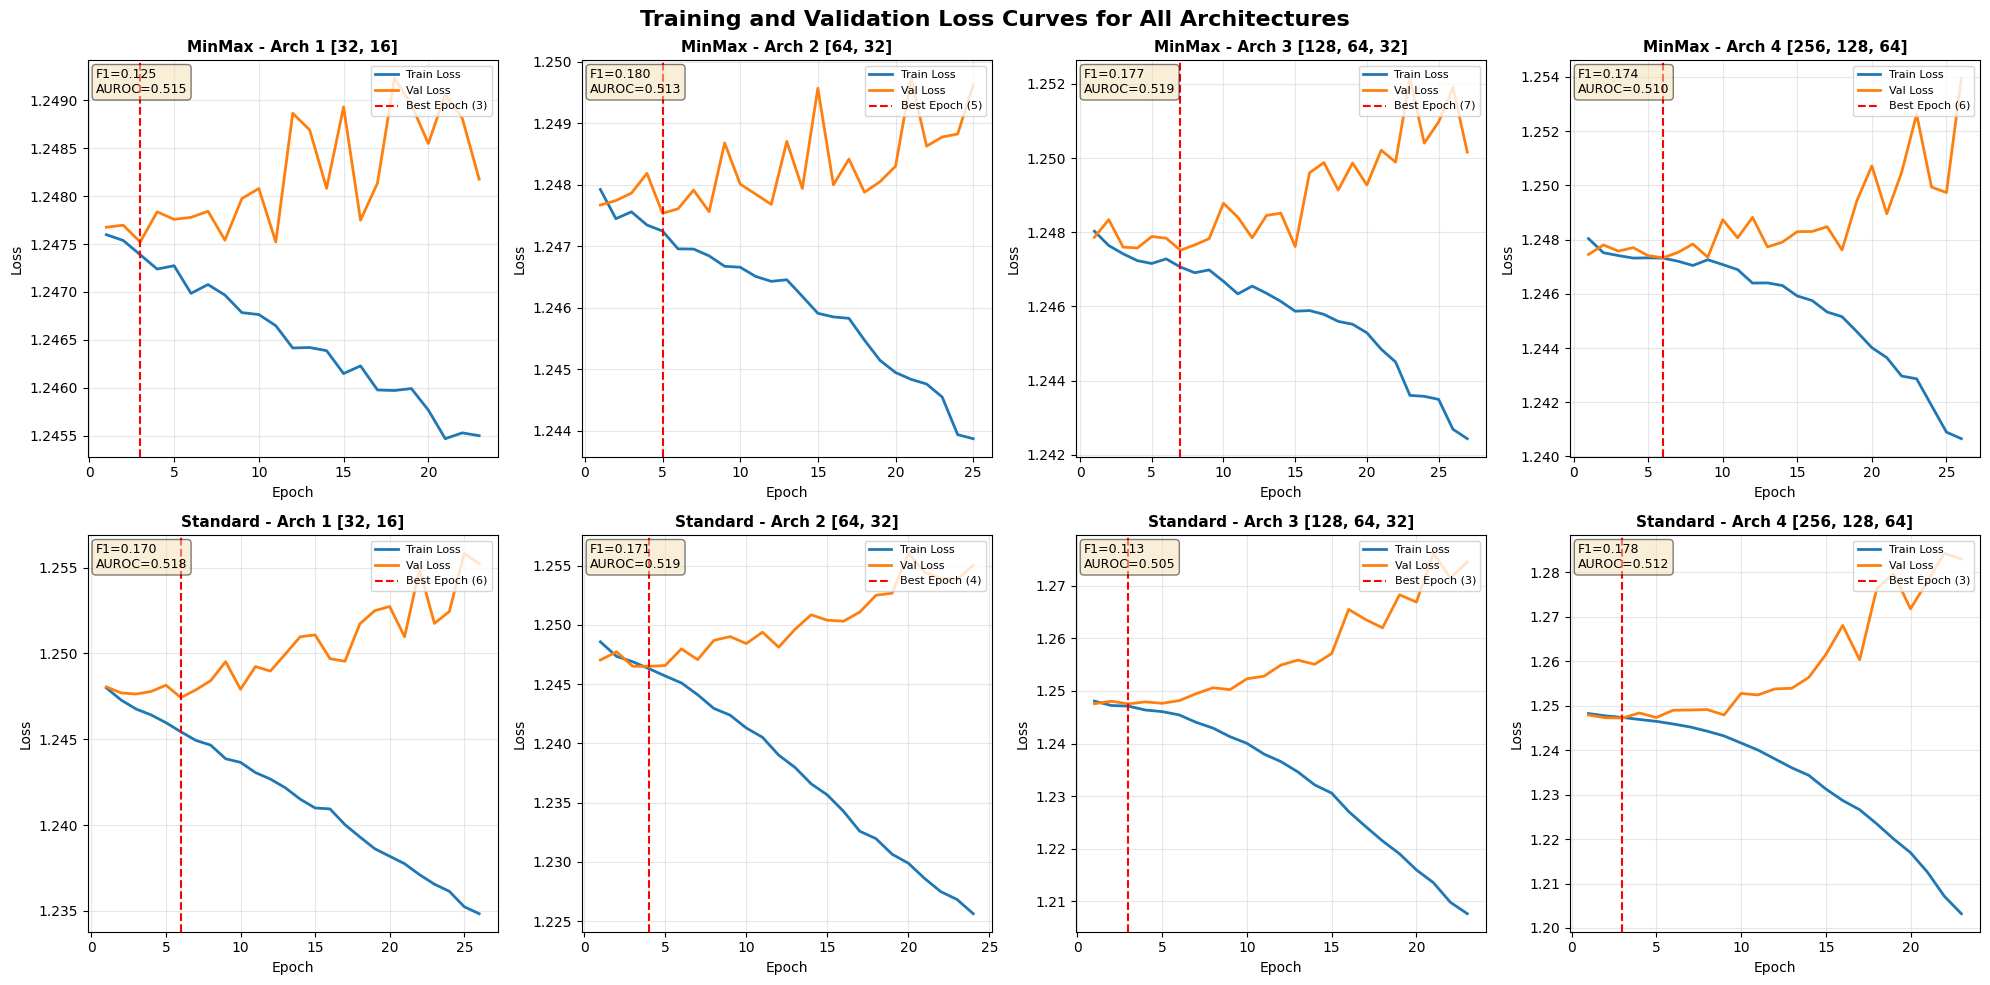


Loss curves plotted for all 8 model configurations
(4 architectures × 2 scaling methods)


In [ ]:
# Plot Training and Validation Loss Curves for ALL Models
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Training and Validation Loss Curves for All Architectures', fontsize=16, fontweight='bold')

plot_idx = 0
for scaling_name in ['MinMax', 'Standard']:
    results = all_results[scaling_name]
    
    for arch_name in sorted(results.keys()):
        row = plot_idx // 4
        col = plot_idx % 4
        ax = axes[row, col]
        
        m = results[arch_name]
        train_losses = m['train_losses']
        val_losses = m['val_losses']
        best_epoch = m['best_epoch']
        
        epochs = range(1, len(train_losses) + 1)
        
        ax.plot(epochs, train_losses, label='Train Loss', linewidth=2)
        ax.plot(epochs, val_losses, label='Val Loss', linewidth=2)
        ax.axvline(x=best_epoch, color='red', linestyle='--', linewidth=1.5, label=f'Best Epoch ({best_epoch})')
        
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel('Loss', fontsize=10)
        ax.set_title(f'{scaling_name} - {arch_name} {m["hidden_layers"]}', fontsize=11, fontweight='bold')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # Add performance metrics as text
        textstr = f'F1={m["f1"]:.3f}\nAUROC={m["auroc"]:.3f}'
        ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plot_idx += 1

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("Loss curves plotted for all 8 model configurations")
print("(4 architectures 2 scaling methods)")
print("="*80)

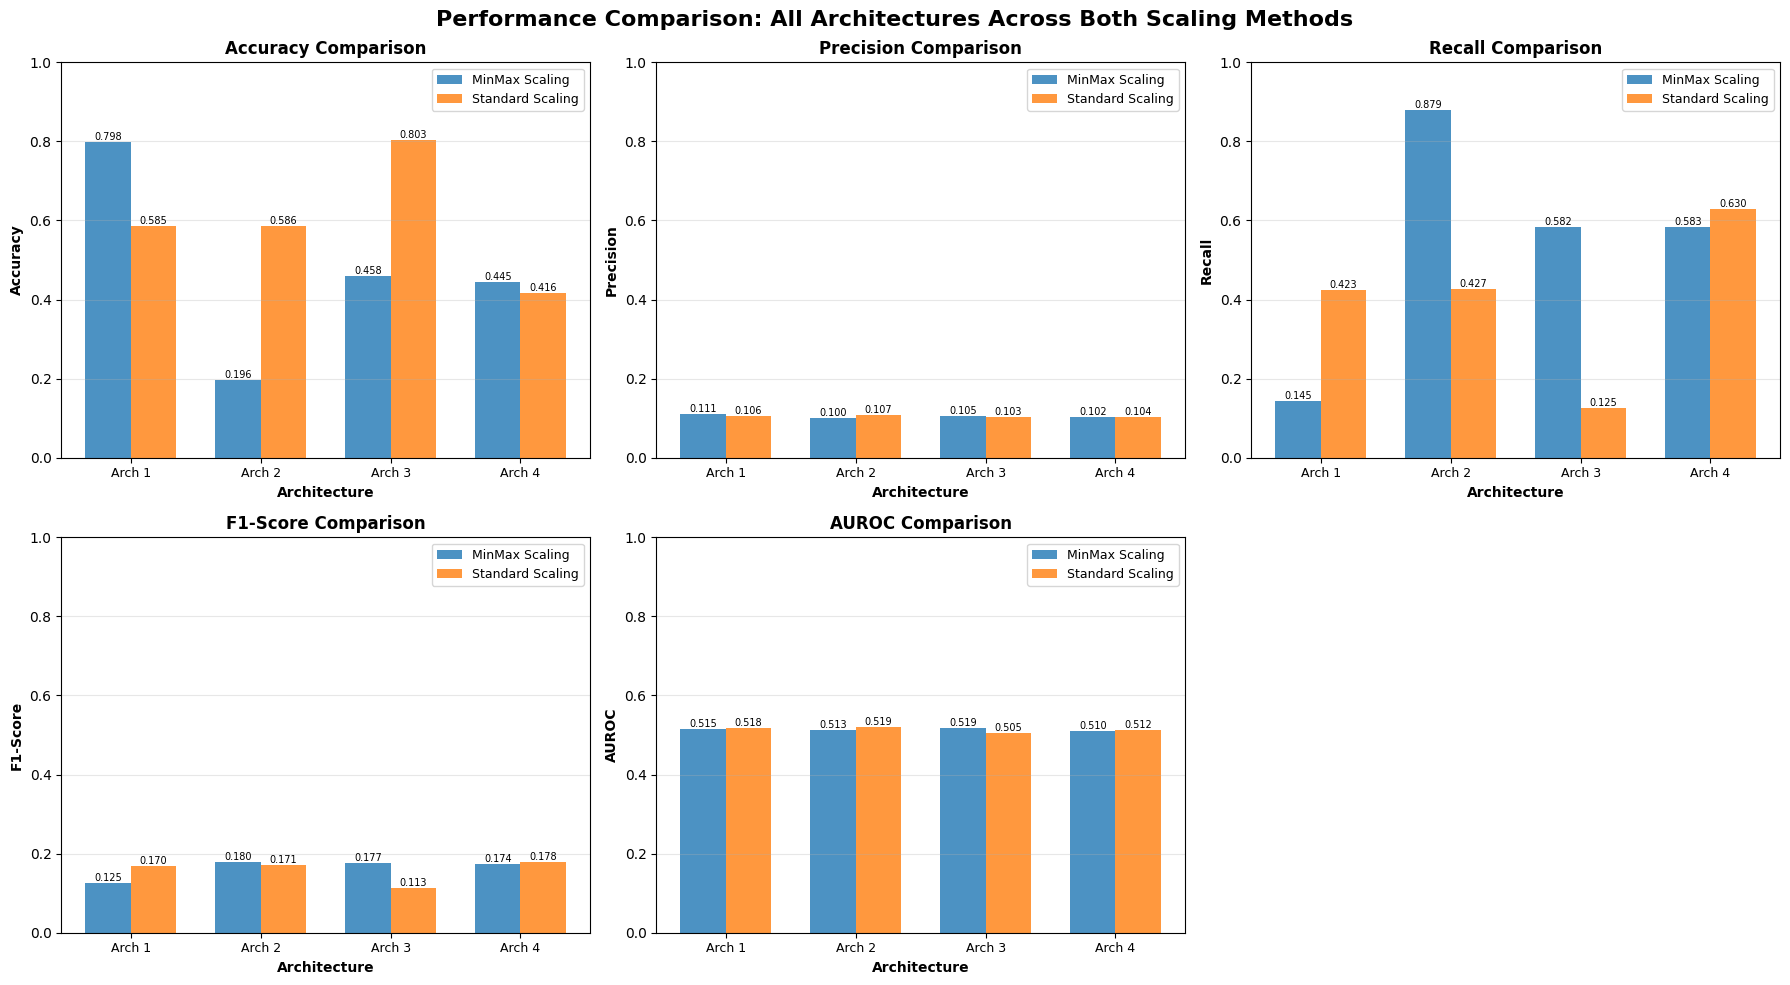


Performance comparison charts generated for all models


In [ ]:
# Performance Comparison Bar 
import matplotlib.pyplot as plt
import numpy as np

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'auroc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUROC']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Performance Comparison: All Architectures Across Both Scaling Methods', fontsize=16, fontweight='bold')

for idx, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    minmax_values = [all_results['MinMax'][arch][metric] for arch in sorted(all_results['MinMax'].keys())]
    standard_values = [all_results['Standard'][arch][metric] for arch in sorted(all_results['Standard'].keys())]
    
    x = np.arange(len(minmax_values))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, minmax_values, width, label='MinMax Scaling', alpha=0.8)
    bars2 = ax.bar(x + width/2, standard_values, width, label='Standard Scaling', alpha=0.8)
    
    ax.set_xlabel('Architecture', fontsize=10, fontweight='bold')
    ax.set_ylabel(label, fontsize=10, fontweight='bold')
    ax.set_title(f'{label} Comparison', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Arch 1', 'Arch 2', 'Arch 3', 'Arch 4'], fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1.0])
    
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=7)

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("Performance comparison charts generated for all models")
print("="*80)

FINAL MODEL: COMPREHENSIVE TEST SET EVALUATION

Model Configuration:
  Scaling Method:    MinMax
  Architecture:      Arch 2
  Hidden Layers:     [64, 32]
  Input Dimension:   10
  Total Parameters:  2817
  Weights File:      best_model_MinMax_Arch_2.pth
  Best Epoch:        5
  Best Val Loss:     1.2475

PERFORMANCE METRICS ON TEST SET
  Accuracy:   0.1961
  Precision:  0.1002
  Recall:     0.8793
  F1-score:   0.1799
  AUROC:      0.5134

CONFUSION MATRIX

[[ 2794 20481]
 [  313  2280]]

True Negatives (TN):  2794
False Positives (FP): 20481
False Negatives (FN): 313
True Positives (TP):  2280

CLASSIFICATION REPORT

              precision    recall  f1-score   support

 No Diabetes       0.90      0.12      0.21     23275
    Diabetes       0.10      0.88      0.18      2593

    accuracy                           0.20     25868
   macro avg       0.50      0.50      0.20     25868
weighted avg       0.82      0.20      0.21     25868



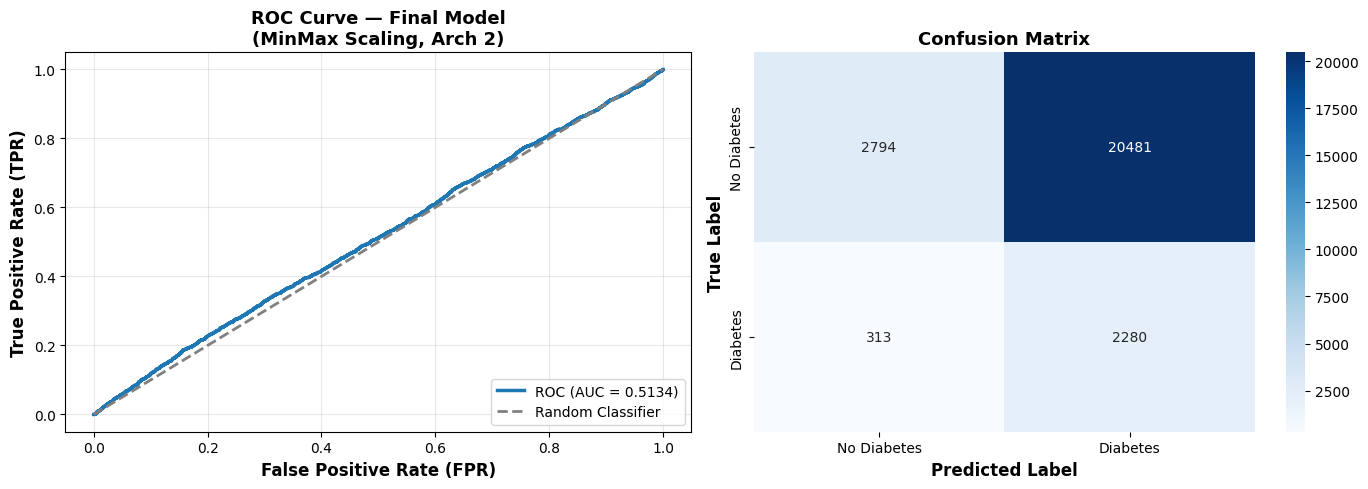


Final model evaluation complete!


In [ ]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

m = all_results[best_scaling][best_arch]
hidden_layers = m['hidden_layers']
model_path = m['model_path']

data = results_by_scaling[best_scaling]
X_test_tensor = data['X_test_tensor'].to(device)
y_test_tensor = data['y_test_tensor'].to(device)
y_test = data['y_test']  # numpy array float32 0/1

input_dim = X_test_tensor.shape[1]
model = DiabetesFNN(input_dim, hidden_layers).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

with torch.no_grad():
    logits = model(X_test_tensor)
    y_prob = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)

y_true = y_test.reshape(-1).astype(np.float32)
y_pred = (y_prob >= 0.5).astype(np.float32)

# --- Compute Metrics ---
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
auroc = roc_auc_score(y_true, y_prob)

print("="*80)
print("FINAL MODEL: COMPREHENSIVE TEST SET EVALUATION")
print("="*80)
print(f"\nModel Configuration:")
print(f"  Scaling Method:    {best_scaling}")
print(f"  Architecture:      {best_arch}")
print(f"  Hidden Layers:     {hidden_layers}")
print(f"  Input Dimension:   {input_dim}")
print(f"  Total Parameters:  {sum(p.numel() for p in model.parameters())}")
print(f"  Weights File:      {model_path}")
print(f"  Best Epoch:        {m['best_epoch']}")
print(f"  Best Val Loss:     {m['best_val_loss']:.4f}")

print(f"\n{'='*80}")
print("PERFORMANCE METRICS ON TEST SET")
print("="*80)
print(f"  Accuracy:   {accuracy:.4f}")
print(f"  Precision:  {precision:.4f}")
print(f"  Recall:     {recall:.4f}")
print(f"  F1-score:   {f1:.4f}")
print(f"  AUROC:      {auroc:.4f}")

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
print(f"\n{'='*80}")
print("CONFUSION MATRIX")
print("="*80)
print(f"\n{cm}")
print(f"\nTrue Negatives (TN):  {cm[0, 0]}")
print(f"False Positives (FP): {cm[0, 1]}")
print(f"False Negatives (FN): {cm[1, 0]}")
print(f"True Positives (TP):  {cm[1, 1]}")

# --- Classification Report ---
print(f"\n{'='*80}")
print("CLASSIFICATION REPORT")
print("="*80)
print("\n" + classification_report(y_true, y_pred, target_names=['No Diabetes', 'Diabetes'], zero_division=0))

# --- Create Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
axes[0].plot(fpr, tpr, linewidth=2.5, label=f'ROC (AUC = {auroc:.4f})')
axes[0].plot([0, 1], [0, 1], linestyle='--', linewidth=2, color='gray', label='Random Classifier')
axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
axes[0].set_title(f'ROC Curve — Final Model\n({best_scaling} Scaling, {best_arch})', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=axes[1],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[1].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("Final model evaluation complete!")
print("="*80)

In [21]:
print("="*80)
print("COMPLETE SUMMARY OF ALL RESULTS")
print("="*80)

for scaling_name in ['MinMax', 'Standard']:
    print(f"\n{scaling_name} Scaling:")
    print("-" * 60)
    results = all_results[scaling_name]
    for arch, metrics in results.items():
        print(
            f"{arch} {metrics['hidden_layers']}: "
            f"Acc={metrics['accuracy']:.4f}, Prec={metrics['precision']:.4f}, "
            f"Rec={metrics['recall']:.4f}, F1={metrics['f1']:.4f}, AUROC={metrics['auroc']:.4f}, "
            f"best_epoch={metrics['best_epoch']}"
        )

COMPLETE SUMMARY OF ALL RESULTS

MinMax Scaling:
------------------------------------------------------------
Arch 1 [32, 16]: Acc=0.7979, Prec=0.1108, Rec=0.1446, F1=0.1255, AUROC=0.5145, best_epoch=3
Arch 2 [64, 32]: Acc=0.1961, Prec=0.1002, Rec=0.8793, F1=0.1799, AUROC=0.5134, best_epoch=5
Arch 3 [128, 64, 32]: Acc=0.4584, Prec=0.1046, Rec=0.5823, F1=0.1773, AUROC=0.5188, best_epoch=7
Arch 4 [256, 128, 64]: Acc=0.4450, Prec=0.1022, Rec=0.5827, F1=0.1739, AUROC=0.5099, best_epoch=6

Standard Scaling:
------------------------------------------------------------
Arch 1 [32, 16]: Acc=0.5853, Prec=0.1063, Rec=0.4234, F1=0.1699, AUROC=0.5182, best_epoch=6
Arch 2 [64, 32]: Acc=0.5857, Prec=0.1070, Rec=0.4265, F1=0.1711, AUROC=0.5193, best_epoch=4
Arch 3 [128, 64, 32]: Acc=0.8032, Prec=0.1032, Rec=0.1253, F1=0.1132, AUROC=0.5054, best_epoch=3
Arch 4 [256, 128, 64]: Acc=0.4159, Prec=0.1035, Rec=0.6302, F1=0.1778, AUROC=0.5116, best_epoch=3
